In [3]:
import pandas as pd

df=pd.read_csv("Diabetes_prediction.csv")
print("Loaded")

Loaded


In [4]:
print(df.head(5))
print(df.columns)

   Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0            2  115.863387      56.410731      24.336736   94.385783   
1            2   92.490122      70.615520      23.443591  138.652426   
2            1   88.141469      63.262618      23.404364  149.358082   
3            2  108.453101      67.793632      20.751580  108.751638   
4            1  127.849443      94.725685      22.603078   25.269987   

         BMI  DiabetesPedigreeFunction        Age  Diagnosis  
0  26.455940                  0.272682  20.100494          0  
1  23.910167                  0.665160  44.912281          0  
2  21.948250                  0.676022  48.247873          1  
3  24.209304                  0.289636  42.749868          0  
4  32.997477                  0.601315  32.797789          0  
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Diagnosis'],
      dtype='str')


In [9]:
print(df.describe())
print(df.shape)
print(df.info())

       Pregnancies      Glucose  BloodPressure  SkinThickness      Insulin  \
count  1000.000000  1000.000000    1000.000000    1000.000000  1000.000000   
mean      1.771000    99.440607      72.179837      23.278316    84.582679   
std       1.354398    19.470730      13.882017       1.173807    74.872733   
min       0.000000    30.571402      31.401487      19.369987  -165.310033   
25%       1.000000    86.145927      62.795447      22.501591    35.076535   
50%       2.000000    99.458362      71.909588      23.275225    84.442232   
75%       3.000000   113.264556      82.082660      24.052022   134.267842   
max       8.000000   161.238939     110.723715      26.917654   317.701852   

               BMI  DiabetesPedigreeFunction          Age   Diagnosis  
count  1000.000000               1000.000000  1000.000000  1000.00000  
mean     25.433600                  0.449383    43.281798     0.30600  
std       3.690223                  0.199334    14.465398     0.46106  
min      

In [7]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Diagnosis                   0
dtype: int64


In [8]:
print(df.duplicated().sum())

0


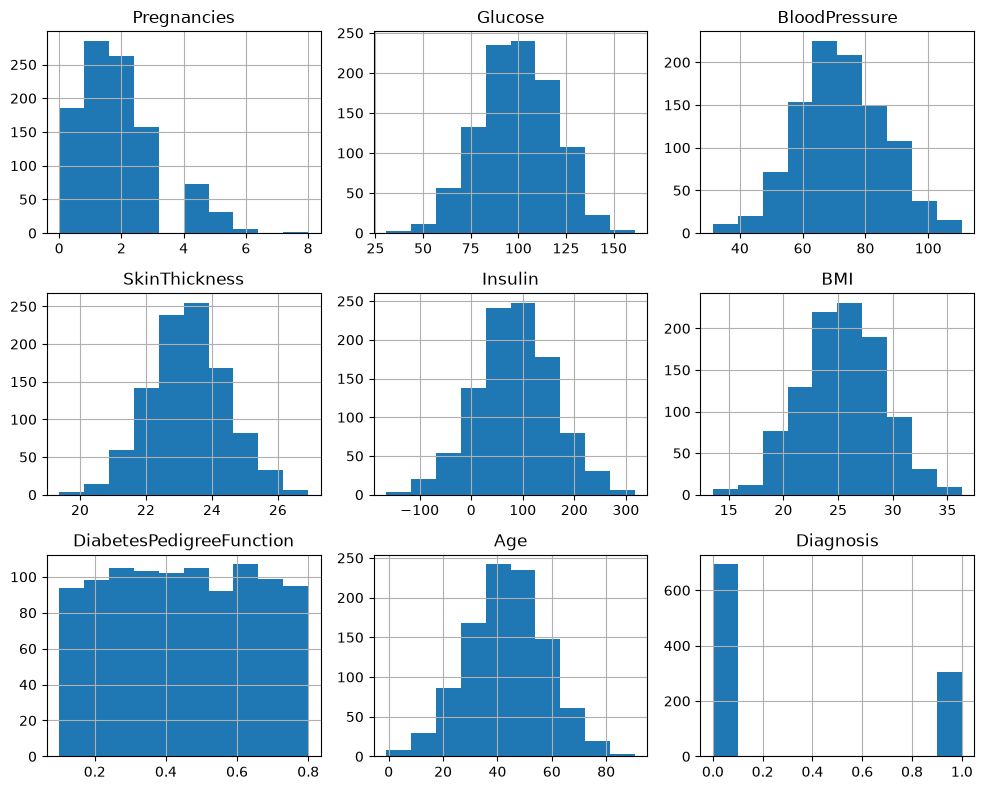

In [10]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

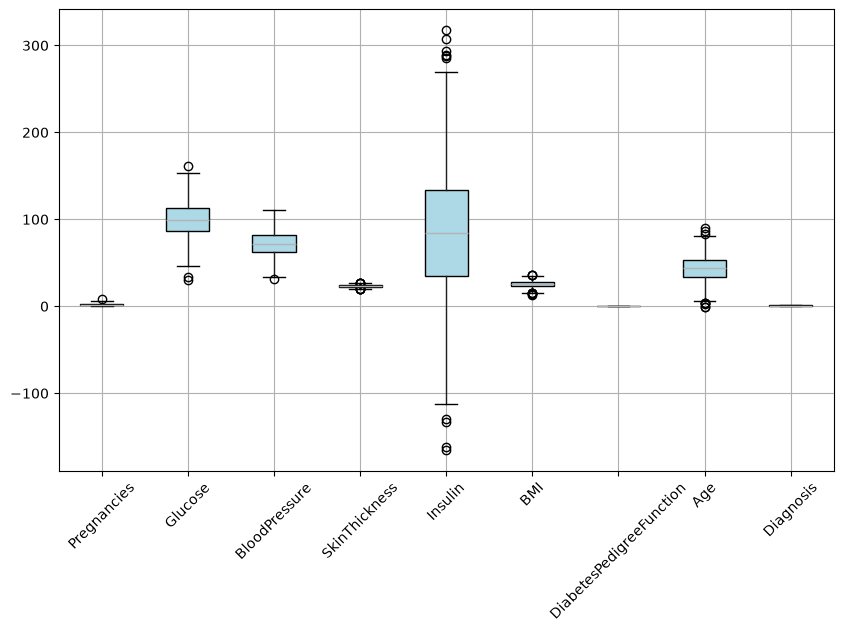

In [16]:
plt.figure(figsize=(10,6))
df.boxplot(
    patch_artist=True,
    boxprops=dict(facecolor="lightblue")
)

plt.xticks(rotation=45)
plt.show()



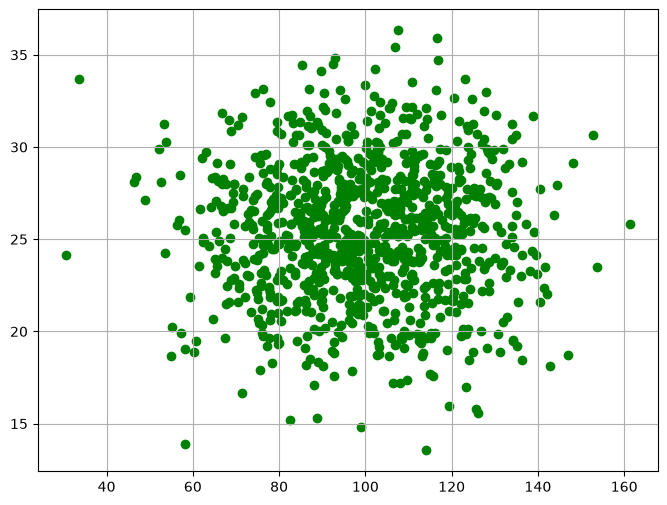

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(df["Glucose"],df["BMI"],color="green")
plt.grid(True)
plt.show()

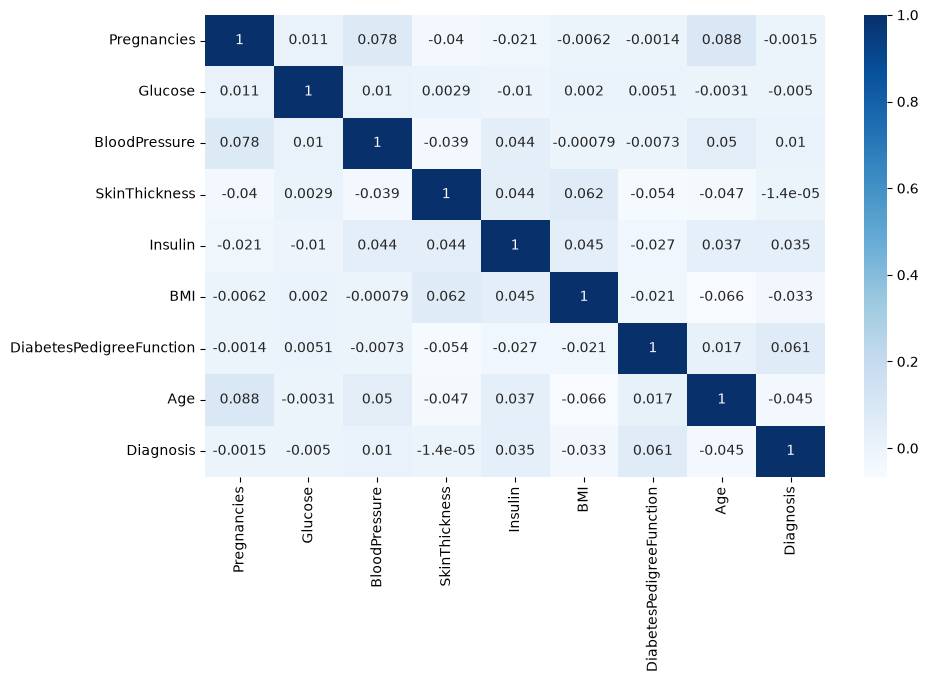

In [19]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap="Blues")
plt.show()

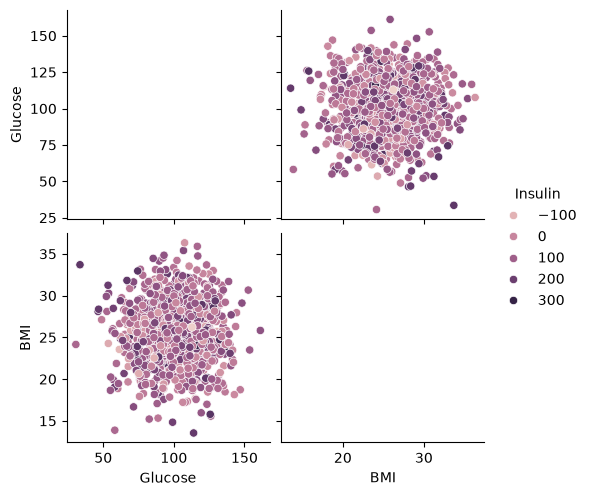

In [20]:
sns.pairplot(df[["Glucose","BMI","Insulin"]],hue="Insulin")
plt.show()

In [21]:
print((df["Glucose"] == 0).sum())
print((df["BloodPressure"] == 0).sum())
print((df["SkinThickness"] == 0).sum())
print((df["Insulin"] == 0).sum())
print((df["BMI"] == 0).sum())

0
0
0
0
0


In [28]:
x= df.drop("Diagnosis", axis=1)
y= df["Diagnosis"]
print("Labeled")

Labeled


In [41]:
from sklearn.preprocessing import StandardScaler

model=StandardScaler()
x_train = model.fit_transform(X_train)
x_test = model.transform(X_test)

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(800, 8)
(800,)
(200, 8)
(200,)


In [42]:
print(x_train.head(5))
print(y_train.head(5))
print(x_test.head(5))
print(y_test.head(5))

     Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
29             1  111.441856      66.454235      23.479227   44.278730   
535            3   58.066486      52.373287      22.845978  198.619401   
695            1  106.779874      71.683909      21.474644  145.709109   
557            3  130.406785      85.942208      24.646644  -83.329864   
836            3  130.271959      69.139865      23.685052   80.406452   

           BMI  DiabetesPedigreeFunction        Age  
29   29.281046                  0.755596  54.278127  
535  19.046567                  0.776325  54.856958  
695  25.358900                  0.560211  24.542146  
557  25.705368                  0.335316  48.437921  
836  31.725638                  0.161689  17.637715  
29     1
535    0
695    0
557    1
836    0
Name: Diagnosis, dtype: int64
     Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
521            0   96.606637      76.463154      25.019103  149.553084   
737     

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model=DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.51


In [44]:
from  sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=100000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.685


In [47]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)
print(cm)

[[126  11]
 [ 60   3]]


In [48]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

select=SelectKBest(score_func=f_classif,k=1)
x=select.fit_transform(x_train,y_train)
print(select.scores_)
print(x_train.columns[select.get_support()])

[9.79797212e-04 9.00293612e-01 1.19044436e-02 1.36790973e-01
 1.26560325e+00 2.56425608e-02 5.06039569e+00 6.10626161e+00]
Index(['Age'], dtype='str')


In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.92      0.78       137
           1       0.21      0.05      0.08        63

    accuracy                           0.65       200
   macro avg       0.45      0.48      0.43       200
weighted avg       0.53      0.65      0.56       200

